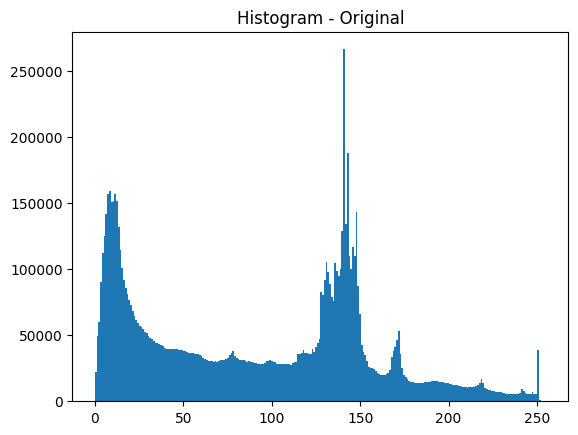

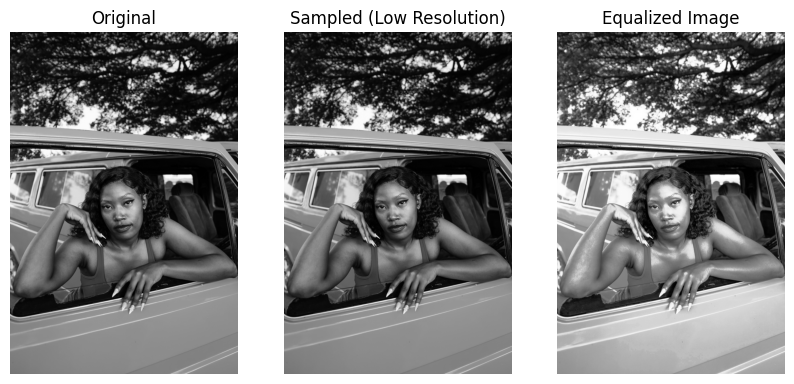

In [3]:
#1

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
img = cv2.imread('/dwayne-joe-rLLP1G4ZRT0-unsplash.jpg')
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# 1. Sampling (Reduce resolution)
sampled = cv2.resize(gray, None, fx=0.5, fy=0.5, interpolation=cv2.INTER_NEAREST)

# 2. Histogram of original
plt.figure()
plt.hist(gray.ravel(), bins=256)
plt.title("Histogram - Original")

# 3. Histogram Equalization
equalized = cv2.equalizeHist(gray)

# 4. Display results
plt.figure(figsize=(10,6))

plt.subplot(1,3,1)
plt.imshow(gray, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(sampled, cmap='gray')
plt.title("Sampled (Low Resolution)")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(equalized, cmap='gray')
plt.title("Equalized Image")
plt.axis('off')

plt.show()

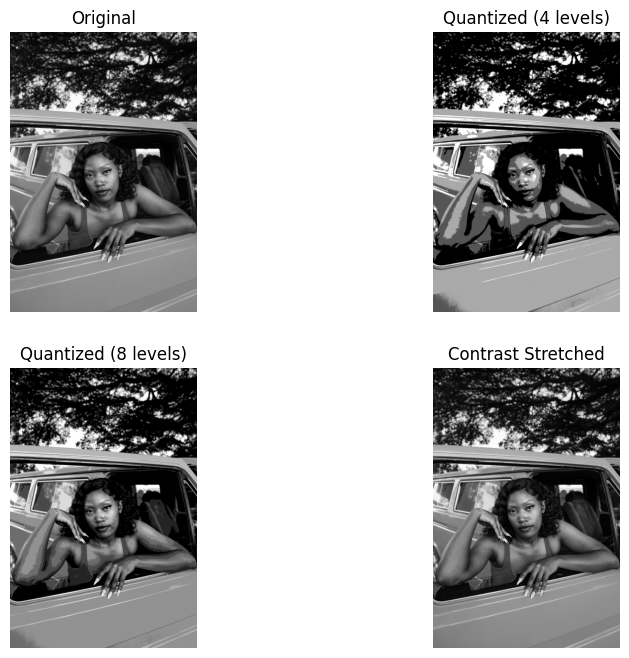

In [6]:
#2 Aim: To study quantization effects and contrast enhancement techniques. • Quantize image (4 & 8 levels) • Perform contrast stretching • Analyze visual differences

import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image in grayscale
image = cv2.imread('/dwayne-joe-rLLP1G4ZRT0-unsplash.jpg', 0)

# Function for quantization
def quantize(img, levels):
    step = 256 // levels
    quantized = (img // step) * step
    return quantized

# Quantization
img_q4 = quantize(image, 4)
img_q8 = quantize(image, 8)

# Contrast Stretching
def contrast_stretch(img):
    min_val = np.min(img)
    max_val = np.max(img)
    stretched = ((img - min_val) / (max_val - min_val)) * 255
    return stretched.astype(np.uint8)

img_cs = contrast_stretch(image)

# Plot results
plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
plt.imshow(image, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(img_q4, cmap='gray')
plt.title("Quantized (4 levels)")
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(img_q8, cmap='gray')
plt.title("Quantized (8 levels)")
plt.axis('off')

plt.subplot(2,2,4)
plt.imshow(img_cs, cmap='gray')
plt.title("Contrast Stretched")
plt.axis('off')

plt.show()

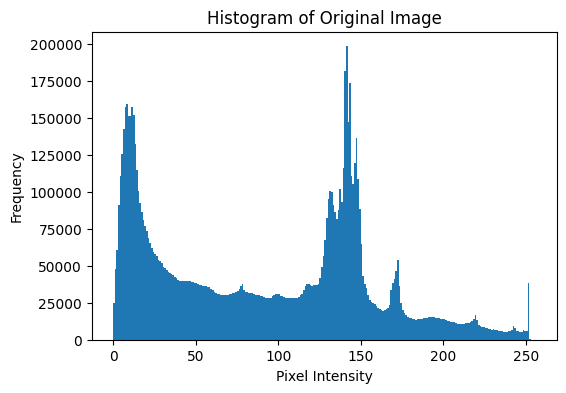

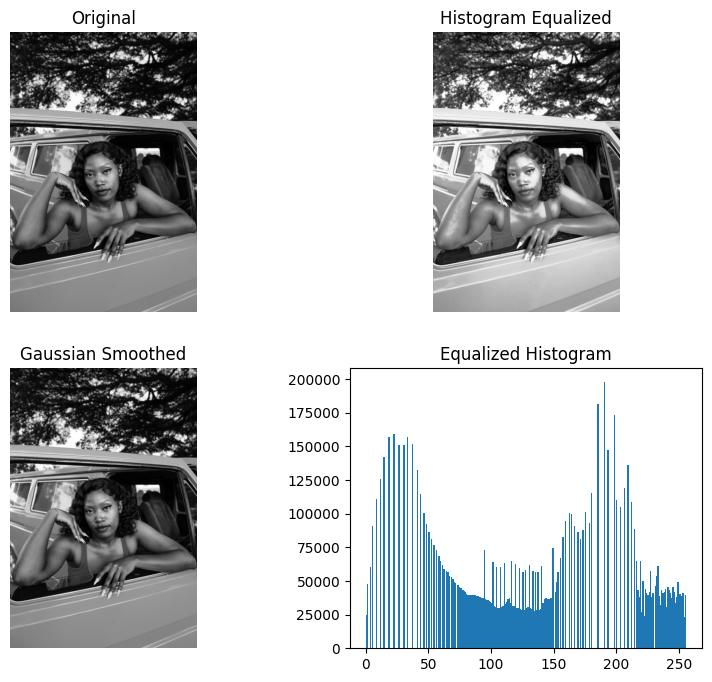

In [8]:
#Q3 Aim: To perform histogram-based enhancement and smoothing. • Plot histogram • Apply histogram equalization • Apply Gaussian filter
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load image
image = cv2.imread('/dwayne-joe-rLLP1G4ZRT0-unsplash.jpg', 0)

# Histogram
plt.figure(figsize=(6,4))
plt.hist(image.ravel(), bins=256, range=[0,256])
plt.title("Histogram of Original Image")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

# Histogram Equalization
img_eq = cv2.equalizeHist(image)

# Gaussian Filter
img_gauss = cv2.GaussianBlur(image, (5,5), 0)

# Display results
plt.figure(figsize=(10,8))

plt.subplot(2,2,1)
plt.imshow(image, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(2,2,2)
plt.imshow(img_eq, cmap='gray')
plt.title("Histogram Equalized")
plt.axis('off')

plt.subplot(2,2,3)
plt.imshow(img_gauss, cmap='gray')
plt.title("Gaussian Smoothed")
plt.axis('off')

plt.subplot(2,2,4)
plt.hist(img_eq.ravel(), bins=256, range=[0,256])
plt.title("Equalized Histogram")

plt.show()

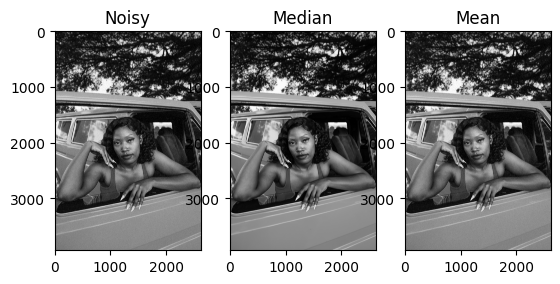

In [11]:
#4Aim: To analyze noise removal using spatial filters. • Add Salt & Pepper noise • Apply median filter • Compare with mean filter
import cv2, numpy as np, matplotlib.pyplot as plt

img = cv2.imread('/dwayne-joe-rLLP1G4ZRT0-unsplash.jpg', 0)

noise = np.random.choice([0,255,None], img.shape, p=[0.02,0.02,0.96])
noisy = img.copy(); noisy[noise==0]=0; noisy[noise==255]=255

median = cv2.medianBlur(noisy,3)
mean = cv2.blur(noisy,(3,3))

plt.subplot(131),plt.imshow(noisy,cmap='gray'),plt.title('Noisy')
plt.subplot(132),plt.imshow(median,cmap='gray'),plt.title('Median')
plt.subplot(133),plt.imshow(mean,cmap='gray'),plt.title('Mean')
plt.show()

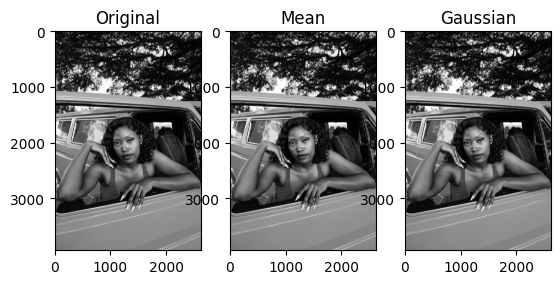

In [12]:
#Q5 Aim: To compare different smoothing techniques. • Apply mean filter • Apply Gaussian filter • Compare results
import cv2, numpy as np, matplotlib.pyplot as plt

img = cv2.imread('/dwayne-joe-rLLP1G4ZRT0-unsplash.jpg', 0)

mean = cv2.blur(img,(5,5))              # Mean filter
gauss = cv2.GaussianBlur(img,(5,5),0)   # Gaussian filter

plt.subplot(131),plt.imshow(img,cmap='gray'),plt.title('Original')
plt.subplot(132),plt.imshow(mean,cmap='gray'),plt.title('Mean')
plt.subplot(133),plt.imshow(gauss,cmap='gray'),plt.title('Gaussian')
plt.show()

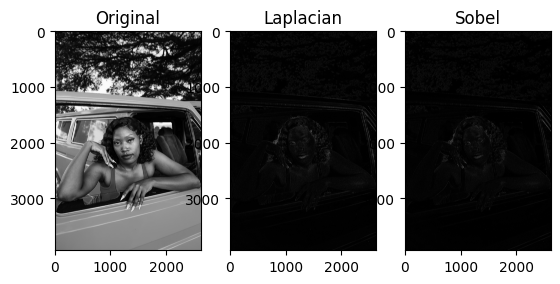

In [17]:
#Q6 Aim: To perform image sharpening and edge detection. • Apply Laplacian filter • Apply Sobel operator • Compare edges
import cv2, numpy as np, matplotlib.pyplot as plt

img = cv2.imread('/dwayne-joe-rLLP1G4ZRT0-unsplash.jpg', 0)

lap = cv2.convertScaleAbs(cv2.Laplacian(img, cv2.CV_64F))
sobel = cv2.convertScaleAbs(cv2.Sobel(img, cv2.CV_64F, 1, 1, ksize=3))

plt.subplot(1,3,1)
plt.imshow(img,cmap='gray')
plt.title('Original')
plt.subplot(1,3,2)
plt.imshow(lap,cmap='gray')
plt.title('Laplacian')
plt.subplot(1,3,3)
plt.imshow(sobel,cmap='gray')
plt.title('Sobel')
plt.show()

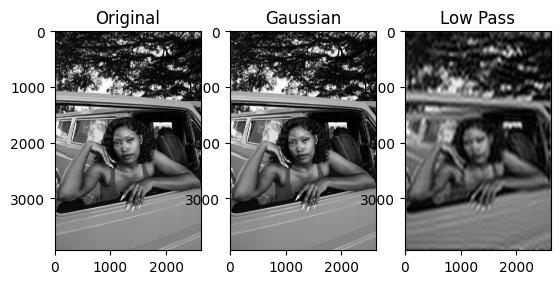

In [18]:
#Q7 Aim: To analyze spatial vs frequency domain smoothing. • Apply Gaussian filter (spatial) • Apply Low Pass Filter (frequency) • Compare outputs
import cv2, numpy as np, matplotlib.pyplot as plt

img = cv2.imread('/dwayne-joe-rLLP1G4ZRT0-unsplash.jpg', 0)

# Spatial (Gaussian)
gauss = cv2.GaussianBlur(img,(5,5),0)

# Frequency (Low Pass Filter)
f = np.fft.fft2(img); fshift = np.fft.fftshift(f)
rows,cols = img.shape; mask = np.zeros((rows,cols),np.uint8)
mask[rows//2-30:rows//2+30, cols//2-30:cols//2+30] = 1
fshift = fshift * mask
img_back = np.abs(np.fft.ifft2(np.fft.ifftshift(fshift)))

plt.subplot(131),plt.imshow(img,cmap='gray'),plt.title('Original')
plt.subplot(132),plt.imshow(gauss,cmap='gray'),plt.title('Gaussian')
plt.subplot(133),plt.imshow(img_back,cmap='gray'),plt.title('Low Pass')
plt.show()

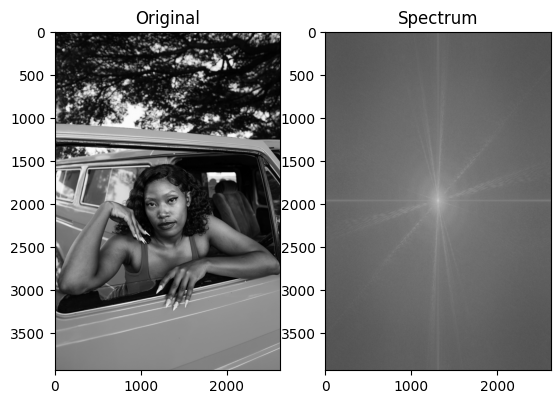

In [20]:
#Q8 Aim: To perform frequency domain transformation and visualization. • Apply FFT • Display magnitude spectrum • Analyze frequency components
import cv2, numpy as np, matplotlib.pyplot as plt

img = cv2.imread('/dwayne-joe-rLLP1G4ZRT0-unsplash.jpg', 0)

f = np.fft.fft2(img)                 # FFT
fshift = np.fft.fftshift(f)          # Shift center

mag = 20*np.log(np.abs(fshift)+1)    # Magnitude spectrum

plt.subplot(121),plt.imshow(img,cmap='gray'),plt.title('Original')
plt.subplot(122),plt.imshow(mag,cmap='gray'),plt.title('Spectrum')
plt.show()

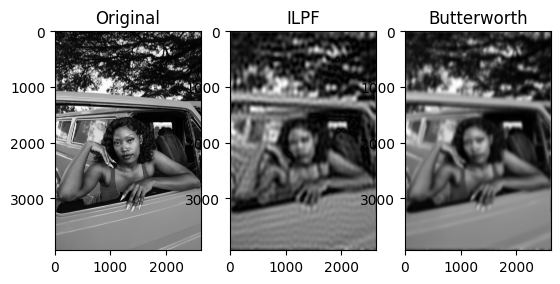

In [21]:
#Q9 Aim: To compare Ideal and Butterworth Low Pass Filters. • Apply ILPF • Apply Butterworth LPF • Compare smoothing
import cv2, numpy as np, matplotlib.pyplot as plt

img = cv2.imread('/dwayne-joe-rLLP1G4ZRT0-unsplash.jpg', 0)
f = np.fft.fftshift(np.fft.fft2(img))
r,c = img.shape; x,y = np.ogrid[:r,:c]; d = np.sqrt((x-r//2)**2+(y-c//2)**2)

# ILPF
H1 = (d <= 30)
ilpf = np.abs(np.fft.ifft2(np.fft.ifftshift(f*H1)))

# Butterworth LPF
H2 = 1/(1+(d/30)**4)
blpf = np.abs(np.fft.ifft2(np.fft.ifftshift(f*H2)))

plt.subplot(131),plt.imshow(img,cmap='gray'),plt.title('Original')
plt.subplot(132),plt.imshow(ilpf,cmap='gray'),plt.title('ILPF')
plt.subplot(133),plt.imshow(blpf,cmap='gray'),plt.title('Butterworth')
plt.show()

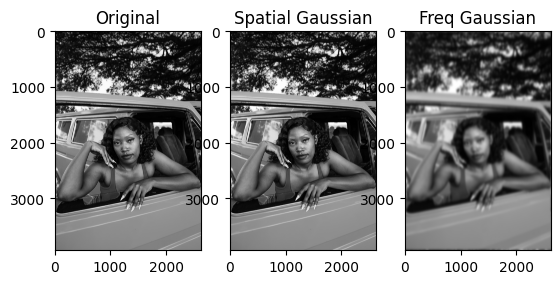

In [22]:
#Q10 Aim: To analyze Gaussian filtering in frequency domain. • Apply Gaussian LPF • Compare with spatial Gaussian filter

import cv2, numpy as np, matplotlib.pyplot as plt

img = cv2.imread('/dwayne-joe-rLLP1G4ZRT0-unsplash.jpg', 0)

# Spatial Gaussian
spatial = cv2.GaussianBlur(img,(5,5),0)

# Frequency Gaussian LPF
f = np.fft.fftshift(np.fft.fft2(img))
r,c = img.shape; x,y = np.ogrid[:r,:c]
d = np.sqrt((x-r//2)**2+(y-c//2)**2)
H = np.exp(-(d**2)/(2*(30**2)))        # Gaussian LPF
freq = np.abs(np.fft.ifft2(np.fft.ifftshift(f*H)))

plt.subplot(131),plt.imshow(img,cmap='gray'),plt.title('Original')
plt.subplot(132),plt.imshow(spatial,cmap='gray'),plt.title('Spatial Gaussian')
plt.subplot(133),plt.imshow(freq,cmap='gray'),plt.title('Freq Gaussian')
plt.show()

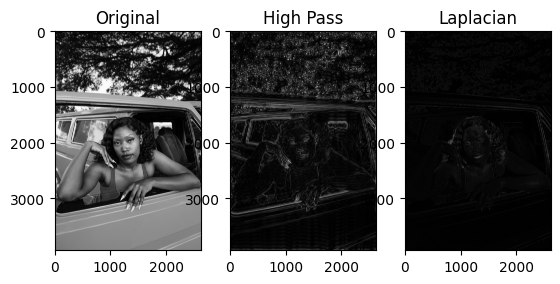

In [23]:
#Q11 Aim: To perform image sharpening using frequency domain techniques. • Apply High Pass Filter • Compare with Laplacian
import cv2, numpy as np, matplotlib.pyplot as plt

img = cv2.imread('/dwayne-joe-rLLP1G4ZRT0-unsplash.jpg', 0)

# Frequency High Pass Filter
f = np.fft.fftshift(np.fft.fft2(img))
r,c = img.shape; x,y = np.ogrid[:r,:c]
mask = np.ones((r,c),np.uint8)
mask[r//2-30:r//2+30, c//2-30:c//2+30] = 0
hp = np.abs(np.fft.ifft2(np.fft.ifftshift(f*mask)))

# Laplacian (spatial sharpening)
lap = cv2.convertScaleAbs(cv2.Laplacian(img, cv2.CV_64F))

plt.subplot(131),plt.imshow(img,cmap='gray'),plt.title('Original')
plt.subplot(132),plt.imshow(hp,cmap='gray'),plt.title('High Pass')
plt.subplot(133),plt.imshow(lap,cmap='gray'),plt.title('Laplacian')
plt.show()

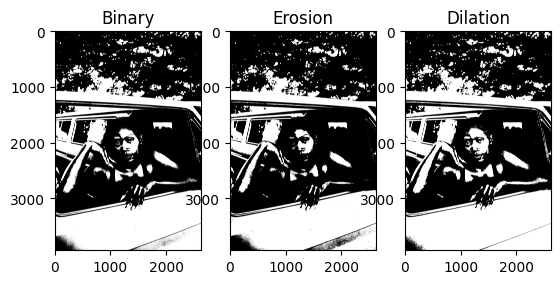

In [24]:
#Q12 Aim: To study morphological operations on binary images. • Apply erosion • Apply dilation • Compare results
import cv2, numpy as np, matplotlib.pyplot as plt

img = cv2.imread('/dwayne-joe-rLLP1G4ZRT0-unsplash.jpg',0)
_,bin = cv2.threshold(img,127,255,cv2.THRESH_BINARY)

k = np.ones((3,3),np.uint8)
er = cv2.erode(bin,k,iterations=1)
di = cv2.dilate(bin,k,iterations=1)

plt.subplot(131),plt.imshow(bin,cmap='gray'),plt.title('Binary')
plt.subplot(132),plt.imshow(er,cmap='gray'),plt.title('Erosion')
plt.subplot(133),plt.imshow(di,cmap='gray'),plt.title('Dilation')
plt.show()

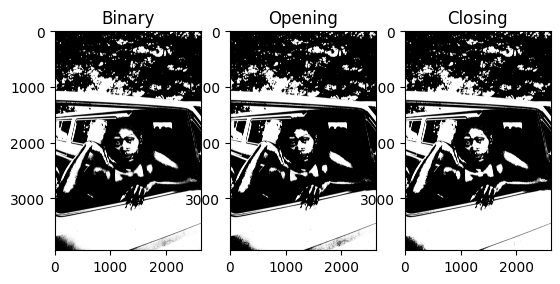

In [26]:
#Q13 Aim: To analyze opening and closing operations. • Perform opening • Perform closing • Compare noise removal
import cv2, numpy as np, matplotlib.pyplot as plt

img = cv2.imread('/dwayne-joe-rLLP1G4ZRT0-unsplash.jpg',0)
_,bin = cv2.threshold(img,127,255,cv2.THRESH_BINARY)

k = np.ones((3,3),np.uint8)
open = cv2.morphologyEx(bin, cv2.MORPH_OPEN, k)
close = cv2.morphologyEx(bin, cv2.MORPH_CLOSE, k)

plt.subplot(131),plt.imshow(bin,cmap='gray'),plt.title('Binary')
plt.subplot(132),plt.imshow(open,cmap='gray'),plt.title('Opening')
plt.subplot(133),plt.imshow(close,cmap='gray'),plt.title('Closing')
plt.show()

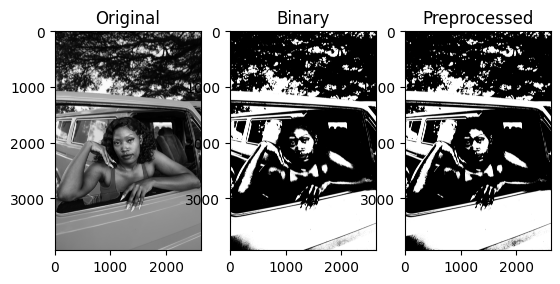

In [27]:
#Q14 Aim: To apply morphology for image preprocessing. • Convert to binary • Apply opening • Prepare for segmentation
import cv2, numpy as np, matplotlib.pyplot as plt

img = cv2.imread('/dwayne-joe-rLLP1G4ZRT0-unsplash.jpg',0)

_,bin = cv2.threshold(img,127,255,cv2.THRESH_BINARY)   # Convert to binary

k = np.ones((3,3),np.uint8)
prep = cv2.morphologyEx(bin, cv2.MORPH_OPEN, k)        # Opening (noise removal)

plt.subplot(131),plt.imshow(img,cmap='gray'),plt.title('Original')
plt.subplot(132),plt.imshow(bin,cmap='gray'),plt.title('Binary')
plt.subplot(133),plt.imshow(prep,cmap='gray'),plt.title('Preprocessed')
plt.show()

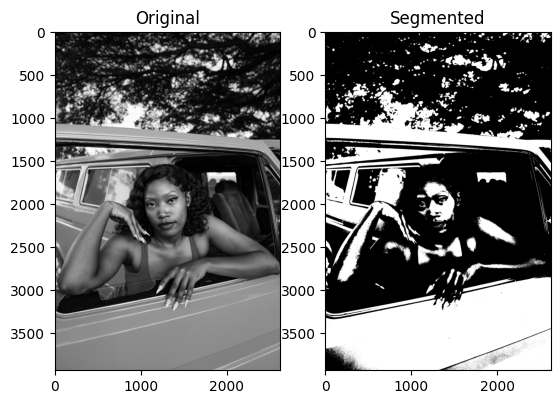

In [28]:
#Q15 Aim: To perform segmentation using thresholding and analyze results. • Apply thresholding • Display segmented image • Analyze output
import cv2, numpy as np, matplotlib.pyplot as plt

img = cv2.imread('/dwayne-joe-rLLP1G4ZRT0-unsplash.jpg',0)

_,th = cv2.threshold(img,127,255,cv2.THRESH_BINARY)   # Thresholding

plt.subplot(121),plt.imshow(img,cmap='gray'),plt.title('Original')
plt.subplot(122),plt.imshow(th,cmap='gray'),plt.title('Segmented')
plt.show()